# Recovering Nonlinear Posterior with COMPASS

In this tutorial, we will:
- generate synthetic data where the posterior is strongly nonlinear;
- train COMPASS;
- compare COMPASS samples against a Monte Carlo reference posterior;
- evaluate two different observations to show shape adaptation;
- show poserior calibration with TARP.

The nonlinear structure comes from:
$$x_1 = \theta_1 + \varepsilon_1, \quad x_2 = \theta_1^2 + \theta_2 + \varepsilon_2$$
which implies a curved ridge roughly along
$$\theta_2 \approx x_2 - \theta_1^2.$$

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from compass import ScoreBasedInferenceModel as SBIm

torch.manual_seed(7)
np.random.seed(7)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1) Problem Setup: A Banana Posterior

We create a simulator with two parameters and two observations. Because of the quadratic term in $x_2$, the posterior is curved and strongly non-Gaussian.

In [2]:
def gen_data_banana(n, noise=0.3):
    """Generate (theta, x) where p(theta | x) has a banana-like shape."""
    theta1 = torch.randn(n)
    theta2 = torch.randn(n)
    x1 = theta1 + torch.randn(n) * noise
    x2 = theta1**2 + theta2 + torch.randn(n) * noise
    theta = torch.stack([theta1, theta2], dim=1)
    x = torch.stack([x1, x2], dim=1)
    return theta, x


def make_dataset(n_train=100_000, n_val=10_000, n_test=1_000):
    theta, x = gen_data_banana(n_train)
    val_theta, val_x = gen_data_banana(n_val)
    test_theta, test_x = gen_data_banana(n_test)
    return (theta, x), (val_theta, val_x), (test_theta, test_x)


def normalize_splits(train, val, test):
    theta, x = train
    val_theta, val_x = val
    test_theta, test_x = test

    theta_mean, theta_std = theta.mean(0), theta.std(0)
    x_mean, x_std = x.mean(0), x.std(0)

    def norm_theta(t):
        return (t - theta_mean) / theta_std

    def norm_x(obs):
        return (obs - x_mean) / x_std

    out = {
        "theta": theta,
        "x": x,
        "val_theta": val_theta,
        "val_x": val_x,
        "test_theta": test_theta,
        "test_x": test_x,
        "theta_mean": theta_mean,
        "theta_std": theta_std,
        "x_mean": x_mean,
        "x_std": x_std,
        "theta_norm": norm_theta(theta),
        "x_norm": norm_x(x),
        "val_theta_norm": norm_theta(val_theta),
        "val_x_norm": norm_x(val_x),
        "test_theta_norm": norm_theta(test_theta),
        "test_x_norm": norm_x(test_x),
        "norm_x_fn": norm_x,
        "denorm_theta_fn": lambda z: z * theta_std + theta_mean,
    }
    return out


def ridge(theta1, x2_value):
    return x2_value - theta1**2

In [3]:
train, val, test = make_dataset()
data = normalize_splits(train, val, test)

print("Train theta/x shape:", data["theta"].shape, data["x"].shape)
print("Validation theta/x shape:", data["val_theta"].shape, data["val_x"].shape)

Train theta/x shape: torch.Size([100000, 2]) torch.Size([100000, 2])
Validation theta/x shape: torch.Size([10000, 2]) torch.Size([10000, 2])


In [4]:
def plot_observation_space(x, n=25_000):
    idx = torch.randperm(x.shape[0])[:n]
    pts = x[idx]
    plt.figure(figsize=(6, 5))
    plt.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.25)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title("Simulator Outputs in Observation Space")
    plt.tight_layout()


def build_and_train_compass(data_dict, hidden_size=128, depth=4, num_heads=4):
    model = SBIm(
        nodes_size=4,
        sde_type="vesde",
        sigma=2,
        hidden_size=hidden_size,
        depth=depth,
        num_heads=num_heads,
        device=device,
    )
    model.train(
        theta=data_dict["theta_norm"],
        x=data_dict["x_norm"],
        theta_val=data_dict["val_theta_norm"],
        x_val=data_dict["val_x_norm"],
        batch_size=64,
        device=device,
        verbose=False,
        path="data/banana_posterior"
    )
    return model


def sample_compass(model, data_dict, x_obs, num_samples=100_000, timesteps=500, order=2):
    x_obs = torch.tensor([x_obs], dtype=torch.float32)
    x_obs_norm = data_dict["norm_x_fn"](x_obs)
    samples_norm = model.sample(
        x=x_obs_norm,
        num_samples=num_samples,
        device=device,
        timesteps=timesteps,
        order=order
    )
    samples = data_dict["denorm_theta_fn"](samples_norm)
    return samples[0].detach().cpu()


def log_posterior(theta1, theta2, x_obs=(1.0, 2.0), noise=0.3):
    x1, x2 = x_obs
    ll_x1 = -0.5 * ((x1 - theta1) / noise) ** 2
    ll_x2 = -0.5 * ((x2 - theta1**2 - theta2) / noise) ** 2
    prior = -0.5 * theta1**2 - 0.5 * theta2**2
    return ll_x1 + ll_x2 + prior


def rejection_reference(x_obs, n_ref=2_000_000):
    theta1_prop = torch.randn(n_ref)
    theta2_prop = torch.randn(n_ref)
    log_p = log_posterior(theta1_prop, theta2_prop, x_obs=x_obs)
    log_p = log_p - log_p.max()
    accept = torch.rand(n_ref) < torch.exp(log_p)
    return theta1_prop[accept].cpu(), theta2_prop[accept].cpu()


def compare_posteriors(ref_t1, ref_t2, compass_samples, x_obs, xlim, ylim):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(ref_t1, ref_t2, alpha=0.25, s=1, c="gray")
    axes[0].set_title("Reference (Rejection Sampling)")

    axes[1].scatter(compass_samples[:, 0], compass_samples[:, 1], alpha=0.25, s=1, c="#1f77b4")
    axes[1].set_title("COMPASS Posterior Samples")

    t = torch.linspace(xlim[0], xlim[1], 200)
    ridge_curve = ridge(t, x_obs[1])

    for ax in axes:
        ax.plot(t.numpy(), ridge_curve.numpy(), "r--", lw=1.6, label=r"$\theta_2 \approx x_2 - \theta_1^2$")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(r"$\theta_1$")
        ax.set_ylabel(r"$\theta_2$")
        ax.legend()

    fig.suptitle(fr"Posterior $p(\theta_1, \theta_2 \mid x_1={x_obs[0]}, x_2={x_obs[1]})$", fontsize=13)
    plt.tight_layout()


def contour_overlay(ref_t1, ref_t2, compass_samples, x_obs, xlim, ylim):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    datasets = [
        (axes[0], ref_t1.numpy(), ref_t2.numpy(), "Reference", "Greys"),
        (axes[1], compass_samples[:, 0].numpy(), compass_samples[:, 1].numpy(), "COMPASS", "Blues"),
    ]

    xi, yi = np.mgrid[xlim[0]:xlim[1]:120j, ylim[0]:ylim[1]:120j]
    for ax, t1, t2, title, cmap in datasets:
        kde = gaussian_kde(np.stack([t1, t2]))
        zi = kde(np.stack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
        ax.contourf(xi, yi, zi, levels=80, cmap=cmap, alpha=0.8)
        ax.contour(xi, yi, zi, levels=4, colors="k", linewidths=0.5)
        t = torch.linspace(xlim[0], xlim[1], 200)
        ax.plot(t.numpy(), ridge(t, x_obs[1]).numpy(), "r--", lw=1.5)
        ax.set_title(title)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(r"$\theta_1$")
        ax.set_ylabel(r"$\theta_2$")

    plt.tight_layout()

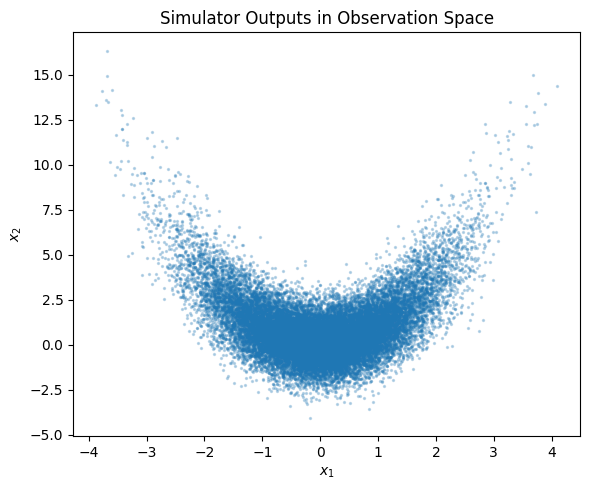

In [5]:
plot_observation_space(data["x"])

## 2) Train COMPASS

COMPASS learns a conditional score model for $p(\theta \mid x)$, then draws posterior samples through reverse-time SDE integration.
The key test here: can it follow the **curved manifold** induced by $x_2 = \theta_1^2 + \theta_2 + \varepsilon$?

In [6]:
sbim = build_and_train_compass(data)

# 3) Inference and Evaluation
We will compare COMPASS samples against a Monte Carlo reference posterior, and evaluate two different observations to show shape adaptation.

100%|██████████| 499/499 [03:43<00:00,  2.23it/s]


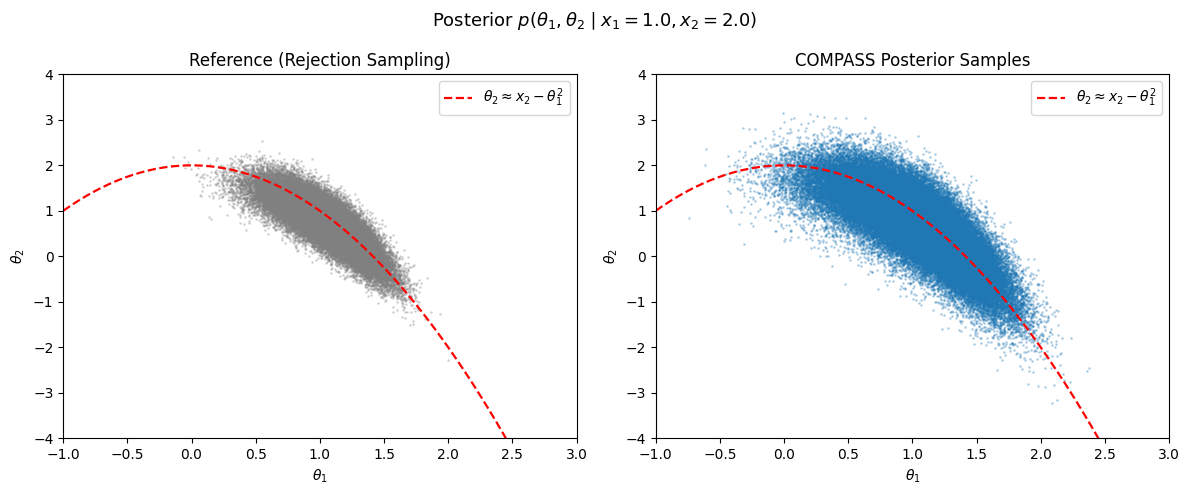

In [7]:
x_obs_a = (1.0, 2.0)
compass_a = sample_compass(sbim, data, x_obs_a)
ref_a_t1, ref_a_t2 = rejection_reference(x_obs_a)

compare_posteriors(
    ref_t1=ref_a_t1,
    ref_t2=ref_a_t2,
    compass_samples=compass_a,
    x_obs=x_obs_a,
    xlim=(-1, 3),
    ylim=(-4, 4),
)

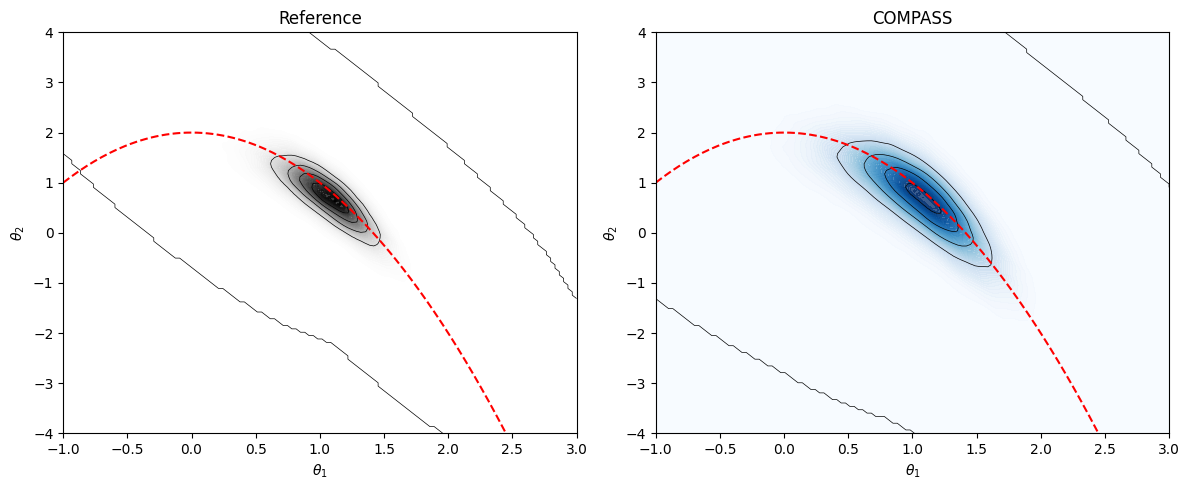

In [8]:
contour_overlay(
    ref_t1=ref_a_t1,
    ref_t2=ref_a_t2,
    compass_samples=compass_a,
    x_obs=x_obs_a,
    xlim=(-1, 3),
    ylim=(-4, 4),
)

### Change the Observation, Keep the Same Model

Now we test a different conditioning input $x=(0,2)$.
If COMPASS learned the posterior geometry well, the sample cloud should bend along the **new** parabola $\theta_2 \approx 2-\theta_1^2$ centered around the updated $x_1$ constraint.

100%|██████████| 499/499 [03:43<00:00,  2.23it/s]


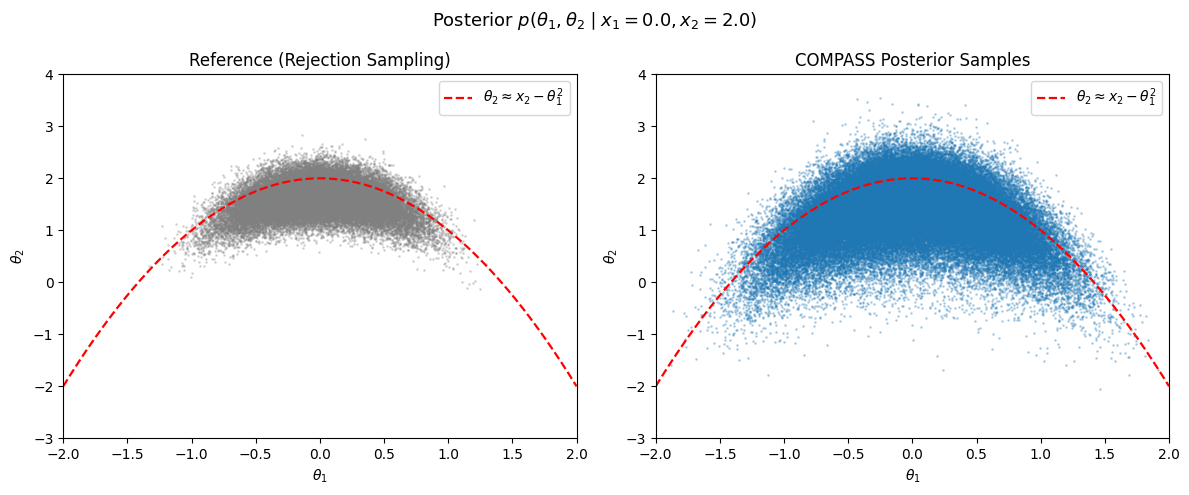

In [9]:
x_obs_b = (0.0, 2.0)
compass_b = sample_compass(sbim, data, x_obs_b)
ref_b_t1, ref_b_t2 = rejection_reference(x_obs_b)

compare_posteriors(
    ref_t1=ref_b_t1,
    ref_t2=ref_b_t2,
    compass_samples=compass_b,
    x_obs=x_obs_b,
    xlim=(-2, 2),
    ylim=(-3, 4),
)

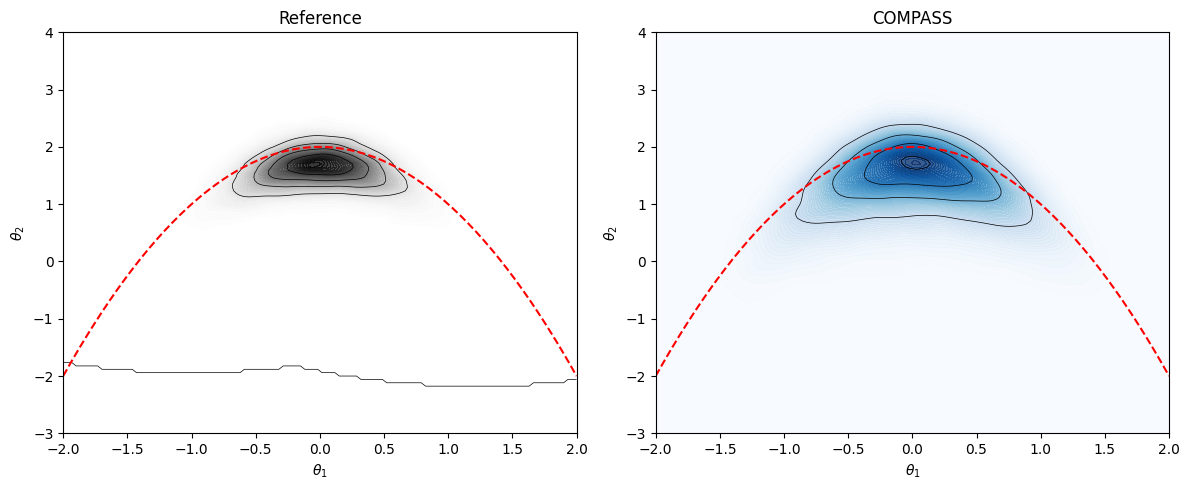

In [10]:
contour_overlay(
    ref_t1=ref_b_t1,
    ref_t2=ref_b_t2,
    compass_samples=compass_b,
    x_obs=x_obs_b,
    xlim=(-2, 2),
    ylim=(-3, 4),
)

## 4) TARP Calibration Plot (Nonlinear Posterior Calibration)

We project posterior samples onto random directions and check whether the true parameter falls inside central posterior intervals of nominal level $\alpha$.

If COMPASS is well calibrated, empirical coverage should follow the diagonal $y=x$.

In [11]:
def _random_unit_vectors(n, dim=2, seed=0):
    rng = np.random.default_rng(seed)
    u = rng.normal(size=(n, dim))
    u = u / np.linalg.norm(u, axis=1, keepdims=True)
    return u


def _central_interval_contains(samples_1d, theta_true_1d, alpha):
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low
    lo, hi = np.quantile(samples_1d, [q_low, q_high])
    return (theta_true_1d >= lo) and (theta_true_1d <= hi)


def tarp_coverage_curve(
    model,
    data_dict,
    n_points=30,
    samples_per_x=512,
    n_proj=32,
    alphas=None,
    timesteps=700,
    seed=0,
    order=1,
):
    if alphas is None:
        alphas = np.linspace(0.1, 0.95, 10)

    rng = np.random.default_rng(seed)
    test_theta = data_dict["test_theta"]
    test_x = data_dict["test_x"]

    n_points = min(n_points, test_x.shape[0])
    idx = rng.choice(test_x.shape[0], size=n_points, replace=False)
    thetas_true = test_theta[idx].cpu().numpy()
    x_batch = test_x[idx]

    directions = _random_unit_vectors(n_proj, dim=2, seed=seed + 1)

    # coverage[proj_id, alpha_id]
    coverage = np.zeros((n_proj, len(alphas)), dtype=float)

    for i in range(n_points):
        x_obs = x_batch[i].unsqueeze(0).to(torch.float32)
        x_obs_norm = data_dict["norm_x_fn"](x_obs)
        samples_norm = model.sample(
            x=x_obs_norm,
            num_samples=samples_per_x,
            device=device,
            timesteps=timesteps,
            order=order,
            snr=0.0,
            corrector_steps=0,
            final_corrector_steps=0,
            verbose=False,
        )
        samples = data_dict["denorm_theta_fn"](samples_norm)[0].detach().cpu().numpy()
        theta_true = thetas_true[i]

        for p, u in enumerate(directions):
            proj_samples = samples @ u
            proj_true = theta_true @ u
            for a_i, alpha in enumerate(alphas):
                coverage[p, a_i] += float(
                    _central_interval_contains(proj_samples, proj_true, alpha)
                )

    coverage /= n_points
    mean_cov = coverage.mean(axis=0)
    std_cov = coverage.std(axis=0)
    tarp_mse = float(np.mean((mean_cov - alphas) ** 2))

    return {
        "alphas": np.array(alphas),
        "mean_cov": mean_cov,
        "std_cov": std_cov,
        "tarp_mse": tarp_mse,
        "n_points": n_points,
        "samples_per_x": samples_per_x,
        "n_proj": n_proj,
    }


def plot_tarp(result, title="TARP Coverage Plot"):
    a = result["alphas"]
    m = result["mean_cov"]
    s = result["std_cov"]

    plt.figure(figsize=(6.2, 5.2))
    plt.plot(a, a, "k--", lw=1.5, label="Ideal calibration")
    plt.plot(a, m, color="#1f77b4", lw=2, label="Empirical coverage")
    plt.fill_between(a, m - s, m + s, color="#1f77b4", alpha=0.2, label="Across projections")
    plt.xlabel("Nominal credible level")
    plt.ylabel("Empirical coverage")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

TARP-MSE (lower is better): 0.00014


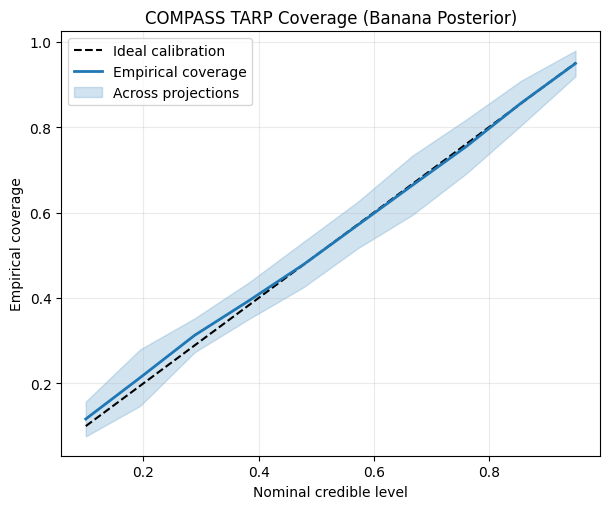

In [12]:
tarp_res = tarp_coverage_curve(
    model=sbim,
    data_dict=data,
    n_points=30,
    samples_per_x=1000,
    n_proj=32,
    alphas=np.linspace(0.1, 0.95, 10),
    timesteps=500,
    seed=42,
    order=1,
    )

plot_tarp(tarp_res, title="COMPASS TARP Coverage (Banana Posterior)")
print(f"TARP-MSE (lower is better): {tarp_res['tarp_mse']:.5f}")